In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dongmin/userdata/open-score-string-quartets


/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import sys
import subprocess
import warnings
from typing import Union, Any, Optional
import shutil
import difflib
from pathlib import Path
from collections import Counter, defaultdict
from operator import itemgetter, contains, eq # contains(A, B) == (B in A), eq(A, B) == (A == B)
from itertools import groupby
from tempfile import NamedTemporaryFile, TemporaryDirectory

import math
import random

import json
import csv
import strictyaml as syaml

from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import numpy as np
import music21

import xml.etree.ElementTree as ET
from modules.lmxe.lmxe import linearize_lmxe, delinearize_lmxe
from modules.lmxe.lmxe import split_tokens_by_key_token
from modules.lmxe.lmxe.Linearizer import SQLinearizer
from modules.lmxe.lmxe.Delinearizer import SQDelinearizer
from modules.lmxe.lmxe.LMXEFile import LMXEFile, LMXEMetadata, get_score_type
from modules.lmxe.lmxe.symbolic.MxlFile import MusicXMLFile
from modules.lmxe.lmxe.symbolic.part_to_score import parts_to_score
from modules.lmxe.lmxe.symbolic.debug_compare import compare_parts

from scripts.mscx_utils import render_lmx
from scripts.utils import get_ts, PathLike, dformat, dprint
from scripts.utils import crop_white_space, load_ossq_metadata

from IPython.core.magic import register_cell_magic
@register_cell_magic
def skip(line, cell):
  return

/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load metadata

In [3]:
ossq_metadata = load_ossq_metadata(Path.cwd() / 'data' / 'scores_w_infos.yaml')
len(ossq_metadata)

122

In [4]:
sq_dataset_dir = Path.home() / 'userdata' / 'open-score-string-quartets' / 'scores'
sq_dataset_dir.exists()

True

In [5]:
pi_dataset_dir = Path.home() / 'userdata' / 'olimpic_dataset_yolo' / 'grandstaff-lmx'
pi_dataset_dir.exists()

True

In [6]:
temp_dir = Path.cwd() / 'temp'
temp_dir.mkdir(exist_ok=True)

## Clean MusicXML ( Remove Dangling Backup-Forward )

In [7]:
data_list = list(ossq_metadata.items())
sample_dir = data_list[0][1]['path']

In [8]:
len(data_list) * 4

488

In [9]:
log_file_path = './clean_musicxml_errors_2025-10-22-12:58:51.log'
log_file_path = './clean_musicxml_errors_2025-10-22-14:23:18.log'
log_file_path = './clean_musicxml_errors_2025-10-22-21:19:07.log'

In [10]:
with open(log_file_path, 'r') as f:
  log = f.read()

log = log.split('\n\n')
log = [l.split('\n')[1:] for l in log if l.strip()]

prob_score_indices = []
prob_parts = []

for score_idx, score in enumerate(log):
  for part in score:
    if '[ERROR]' in part:
      prob_parts.append(part)
      prob_score_indices.append(score_idx)

prob_parts_dict = defaultdict(lambda: defaultdict(list))

for p in prob_parts:
  p = p.replace('[ERROR] ', '')
  sqid = p.split()[0].replace(':', '')
  part_idx = int(p.split()[2].replace(':', '')) - 1
  prob_type = p.split()[5]
  prob_parts_dict[sqid][prob_type].append(part_idx)

prob_parts_dict = {
  k: dict(
    xml_paths=(
      sorted([ 
        p 
        for p in (Path.cwd() / 'scores' / ossq_metadata[k[2:]]['path'] / 'temp').glob('*P*.musicxml') 
        if '_c_major' not in p.stem and '_delin' not in p.stem and '_cleaned' not in p.stem
      ]),
      sorted([ 
        p 
        for p in (Path.cwd() / 'scores' / ossq_metadata[k[2:]]['path'] / 'temp').glob('*P*_cleaned.musicxml')
        if '_delin' not in p.stem and '_c_major' not in p.stem
      ])
    ),
    errors={
      **v
    }
  )
  for k, v in prob_parts_dict.items()
}

In [11]:
len(prob_parts_dict)

85

In [12]:
set([
  k
  for v in prob_parts_dict.values()
  for k in v['errors'].keys()
])

{'differs:'}

In [13]:
with open(log_file_path, 'r') as f:
  log = f.read()

log = log.split('\n\n')
log = [l.split('\n')[1:] for l in log if l.strip()]

prob_parts = []

for score_idx, score in enumerate(log):
  for part in score:
    if '[ERROR]' in part:
      part = part.replace('[ERROR] ', '')
      part = part.split(': ')
      score_id = part[0].replace('sq', '')
      part_idx = int(part[1].split(' ')[1])
      xml_path = sq_dataset_dir / ossq_metadata[score_id]['path'] / 'temp' / f'sq{score_id}_P{part_idx}.musicxml'
      cleaned_xml_path = sq_dataset_dir / ossq_metadata[score_id]['path'] / 'temp' / f'sq{score_id}_P{part_idx}_cleaned.musicxml'
      err_detail = part[-1].split(' ')
      original_count, cleaned_count = err_detail[0], err_detail[-1]

      prob_parts.append((
        f'sq{score_id}',
        xml_path,
        cleaned_xml_path,
        int(original_count),
        int(cleaned_count)
      ))

In [14]:
len(prob_parts)

270

In [15]:
sum([ p[3] - p[4] for p in prob_parts ])

8084

In [ ]:
for score_id, xml_path, cleaned_xml_path, original_count, cleaned_count in prob_parts:
  xml = MusicXMLFile.load_musicxml(xml_path)
  cleaned_xml = MusicXMLFile.load_musicxml(cleaned_xml_path)

  print(f'-------------- {score_id} --------------')

  compare_parts(xml.tree.getroot().find('.//part'), cleaned_xml.tree.getroot().find('.//part'), summary=True)

  print()
  print()

## Linearlizer (MusicXML => LMXE)

In [7]:
sq_musicxml = [
  Path.cwd() / 'scores' / v['path'] / f'sq{k}.musicxml'
  for k, v in ossq_metadata.items()
]

sq_musicxml = list(sorted(sq_musicxml))
len(sq_musicxml), all([p.exists() for p in sq_musicxml])

(122, True)

In [8]:
random.seed(42)
random.seed(950609)
random.seed(940407)
sq_sample = random.choice(sq_musicxml)
sq_sample = Path.cwd() / 'scores' / 'Dvořák,_Antonín/String_Quartet_No.10,_Op.51' / 'sq9137469.musicxml'
print(f"Sample MusicXML: {sq_sample}")

sq_mscore_id = sq_sample.stem

sq_mscore_id

Sample MusicXML: /home/dongmin/userdata/open-score-string-quartets/scores/Dvořák,_Antonín/String_Quartet_No.10,_Op.51/sq9137469.musicxml


'sq9137469'

In [12]:
page_idx = 7
system_idx = 2

In [13]:
sq_lmxe_score_type, sq_lmxe_score = linearize_lmxe(xml=sq_sample)
sq_lmxe_score[page_idx][system_idx]

[ERROR][P:P2 M:0]: Measure rest does not have expected duration. Divisions: 24 Measure duration: 48 b'<note>\n        <rest />\n        <duration>12</duration>\n        <voice>1</voice>\n        <type>eighth</type>\n        </note>\n      '
[ERROR][P:P3 M:0]: Measure rest does not have expected duration. Divisions: 24 Measure duration: 48 b'<note>\n        <rest />\n        <duration>12</duration>\n        <voice>1</voice>\n        <type>eighth</type>\n        </note>\n      '
[ERROR][P:P3 M:X1]: Measure rest does not have expected duration. Divisions: 24 Measure duration: 48 b'<note>\n        <rest />\n        <duration>12</duration>\n        <voice>1</voice>\n        <type>eighth</type>\n        </note>\n      '
[ERROR][P:P4 M:0]: Measure rest does not have expected duration. Divisions: 24 Measure duration: 48 b'<note>\n        <rest />\n        <duration>12</duration>\n        <voice>1</voice>\n        <type>eighth</type>\n        </note>\n      '
[ERROR][P:P4 M:X1]: Measure rest do

['measure part:1 multi key:fifths:-3 clef:G2 staff:1 G5 voice:1 16th stem:down staff:1 beam:begin beam:begin slur:start F5 16th slur:stop F5 16th slur:start E5 16th natural beam:end beam:end slur:stop E5 16th beam:begin beam:begin slur:start F5 16th slur:stop F5 16th slur:start G5 16th beam:end beam:end slur:stop G5 16th beam:begin beam:begin slur:start F5 16th slur:stop F5 16th slur:start E5 16th beam:end beam:end slur:stop E5 16th beam:begin beam:begin slur:start F5 16th slur:stop F5 16th slur:start G5 16th beam:end beam:end slur:stop part:2 multi key:fifths:-3 clef:G2 staff:1 E5 voice:1 16th natural stem:down staff:1 beam:begin beam:begin slur:start D5 16th slur:stop D5 16th slur:start C5 16th sharp beam:end beam:end slur:stop C5 16th beam:begin beam:begin slur:start D5 16th slur:stop D5 16th slur:start E5 16th beam:end beam:end slur:stop E5 16th beam:begin beam:begin slur:start D5 16th slur:stop D5 16th slur:start C5 16th beam:end beam:end slur:stop C5 16th beam:begin beam:begin sl

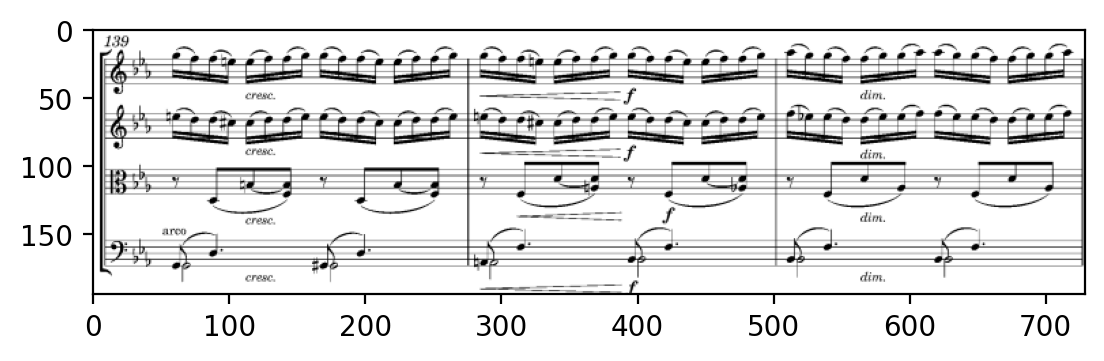

PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Dvořák,_Antonín/String_Quartet_No.10,_Op.51/images/synthetic/crop_resized/sq9137469:0008:0003.png')

In [14]:
sq_sample_image_path = sq_sample.parent / 'images' / 'synthetic' / 'crop_resized' / f'{sq_mscore_id}:{str(page_idx+1).zfill(4)}:{str(system_idx+1).zfill(4)}.png'
plt.imshow(cv2.imread(sq_sample_image_path, cv2.IMREAD_UNCHANGED), cmap='gray')
plt.show()

sq_sample_image_path

In [14]:
from modules.lmxe.lmxe.LMXEFile import LMXEFile, LMXEMetadata

measure_count = 1

for p_idx, page in enumerate(sq_lmxe_score):
  for s_idx, system in enumerate(page):
    m_len = len(system)
    m_st = measure_count
    m_ed = measure_count + m_len - 1

    metadata = LMXEMetadata(
      score_type=sq_lmxe_score_type,
      dataset='open-score-string-quartet',
      score_id=sq_mscore_id,
      page_idx=p_idx + 1,
      system_idx=s_idx + 1,
      measure_start=m_st,
      measure_end=m_ed,
    )

    lmxe_path = temp_dir / f'{sq_mscore_id}:{str(p_idx+1).zfill(4)}:{str(s_idx+1).zfill(4)}.lmxe'

    LMXEFile.write(lmxe_path, '\n'.join(system), metadata)

    measure_count = m_ed + 1

In [12]:
pi_musicxml = pi_dataset_dir.glob('**/*.musicxml')
pi_musicxml = list(sorted(pi_musicxml))
len(pi_musicxml), all([p.exists() for p in pi_musicxml])

(53858, True)

In [ ]:
random.seed(42)
random.seed(940407)
pi_sample = random.choice(pi_musicxml)
print(f"Sample MusicXML: {pi_sample}")

pi_mscore_id = pi_sample.stem

pi_mscore_id

Sample MusicXML: /home/dongmin/userdata/olimpic_dataset_yolo/grandstaff-lmx/beethoven/piano-sonatas/sonata13-4/original_m-60-65.musicxml


'original_m-60-65'

In [14]:
pi_sample_xml = MusicXMLFile.load_musicxml(pi_sample)

In [15]:
pi_lmxe_score_type, pi_lmxe_score = linearize_lmxe(xml=pi_sample_xml)
pi_lmxe_score_type, pi_lmxe_score

('grandstaff',
 [[['measure part:1 grandstaff key:fifths:-3 time beats:2 beat-type:4 clef:G2 staff:1 clef:F4 staff:2 rest voice:1 eighth staff:1 F4 eighth beam:begin chord F5 eighth B4 eighth chord B5 eighth D5 eighth beam:end chord D6 eighth backup half B1 voice:2 16th staff:2 beam:begin beam:begin B2 16th D3 16th chord F3 16th B2 16th beam:end beam:end D3 16th beam:begin beam:begin chord F3 16th B2 16th D3 16th chord F3 16th B2 16th beam:end beam:end',
    'measure part:1 grandstaff F5 voice:1 eighth staff:1 beam:begin chord F6 eighth D5 eighth chord D6 eighth B4 eighth chord B5 eighth F4 eighth beam:end chord F5 eighth backup half D3 voice:2 16th staff:2 beam:begin beam:begin chord F3 16th B2 16th D3 16th chord F3 16th B2 16th beam:end beam:end D3 16th beam:begin beam:begin chord F3 16th B2 16th D3 16th chord F3 16th B2 16th beam:end beam:end',
    'measure part:1 grandstaff G4 voice:1 eighth staff:1 beam:begin chord G5 eighth A4 eighth natural chord A5 eighth natural B4 eighth chor

In [18]:
sample_path_parts = pi_sample.parts
score_id = f'{sample_path_parts[6]}:{sample_path_parts[7]}:{sample_path_parts[8]}:{pi_mscore_id}'

pi_metadata = LMXEMetadata(
  score_type=pi_lmxe_score_type,
  dataset='grandstaff-lmx',
  score_id=score_id,
  measure_start=pi_mscore_id.split('-')[1],
  measure_end=pi_mscore_id.split('-')[2],
)

assert len(pi_lmxe_score) == 1
assert len(pi_lmxe_score[0]) == 1
lmxe_path = temp_dir / f'{pi_mscore_id}.lmxe'

LMXEFile.write(lmxe_path, '\n'.join(pi_lmxe_score[0][0]), pi_metadata)

True

In [38]:
from scripts.mscx_utils import convert_musicxml_to_mscx, render_mscx
from scripts.utils import spawn_processes, terminate_processes
import pdfplumber

display_id = ':99'
script_path = '/home/dongmin/userdata/open-score-string-quartets/mscore'
style_path = '/home/dongmin/userdata/open-score-string-quartets/single-system.mss'
out_sub_dir = temp_dir / pi_sample.stem
out_sub_dir.mkdir(exist_ok=True)

env = os.environ.copy()
env.update({
  'DISPLAY': display_id,
  'QT_QPA_PLATFORM': 'xcb',
  'QT_X11_NO_MITSHM': '1',
  'XDG_RUNTIME_DIR': '/home/dongmin/tmp'
})

process_configs = [
  ['Xvfb', display_id, '-screen', '0', '2560x1440x24', '-ac'],
  [script_path]
]

processes = spawn_processes(process_configs, env)

mscx_path = convert_musicxml_to_mscx(ET.tostring(pi_sample_xml.tree.getroot()).decode(encoding='utf-8'), out_sub_dir, script_path, style_path)

pdf_path = out_sub_dir / 'temp.pdf'

render_mscx(
  mscx_path=mscx_path,
  out_path=pdf_path,
  env=env,
  dpi=300,
  mscore_exec=script_path,
  style_path=style_path,
)

mscx_path.unlink()

pdf = pdfplumber.open(str(pdf_path))
image = pdf.pages[0].to_image(resolution=300)
image_path = out_sub_dir.with_suffix('.png')
image.save(str(image_path))

img = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)
img = crop_white_space(img, ratio=0)

cv2.imwrite(str(image_path), img)

shutil.rmtree(out_sub_dir)

terminate_processes(processes)

CropBox missing from /Page, defaulting to MediaBox


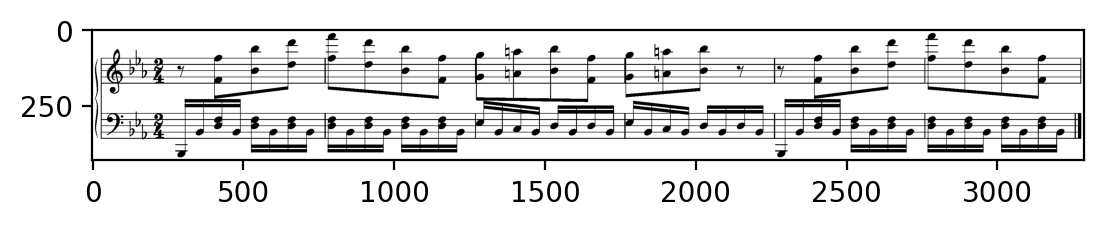

In [39]:
plt.imshow(cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED), cmap='gray')

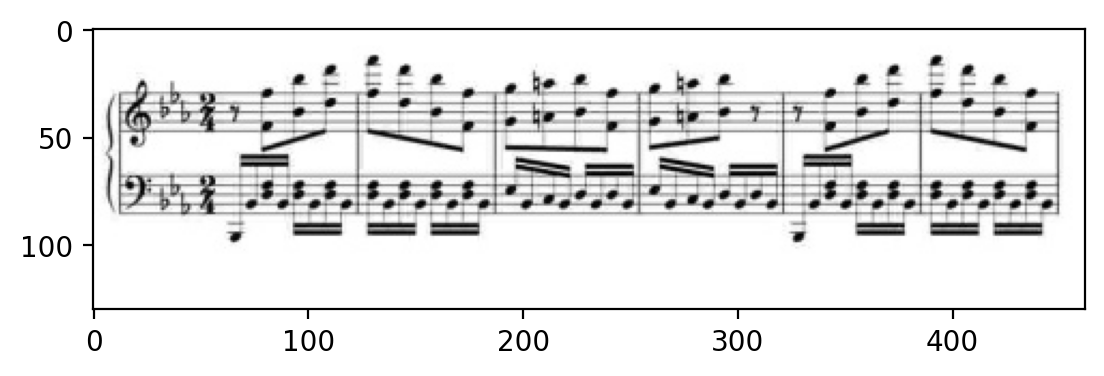

In [40]:
pi_sample_image_path = pi_sample.parent / f'{pi_sample.stem}_yolo_resized.jpg'
plt.imshow(cv2.imread(pi_sample_image_path, cv2.IMREAD_UNCHANGED), cmap='gray')

## Delinearizer (LMXE => MusicXML)

In [42]:
import music21

def remove_consecutive_items(seq):
  return [key for key, group in groupby(seq)]

def compare_note_sequences(file1, file2, tolerance=0.001):
  """Direct comparison of note sequences without MIDI conversion"""
  score1 = music21.converter.parse(file1)
  score2 = music21.converter.parse(file2)

  score1_ts = [
    ts.ratioString
    for p in score1.parts
    for ts in p['TimeSignature']
  ]
  score2_ts = [
    ts.ratioString
    for p in score2.parts
    for ts in p['TimeSignature']
  ]
  if score1_ts != score2_ts:
    return False, f"Time signatures differ: {score1_ts} vs {score2_ts}"

  score1_ks = [ 
    ks.sharps
    for ks in score1.flat.getElementsByClass(music21.key.KeySignature)
  ]
  score1_ks = remove_consecutive_items(score1_ks)
  score2_ks = [
    ks.sharps
    for ks in score2.flat.getElementsByClass(music21.key.KeySignature)
  ]
  score2_ks = remove_consecutive_items(score2_ks)
  print(score1_ks, score2_ks)
  if score1_ks != score2_ks:
    return False, f"Key signatures differ: {str(score1_ks)} vs {str(score2_ks)}"

  def extract_note_data(score):
    """Extract normalized note data from score"""
    notes_data = []
    
    for element in score.flat.notesAndRests:
      if isinstance(element, music21.note.Note):
        notes_data.append({
          'type': 'note',
          'pitch': element.pitch.midi,
          'offset': float(element.offset),
          'duration': float(element.duration.quarterLength)
        })
      elif isinstance(element, music21.chord.Chord):
        notes_data.append({
          'type': 'chord',
          'pitches': tuple(sorted(p.midi for p in element.pitches)),
          'offset': float(element.offset),
          'duration': float(element.duration.quarterLength)
        })
      elif isinstance(element, music21.note.Rest):
        notes_data.append({
          'type': 'rest',
          'offset': float(element.offset),
          'duration': float(element.duration.quarterLength)
        })
    
    return notes_data
  
  notes1 = extract_note_data(score1)
  notes2 = extract_note_data(score2)
  
  if len(notes1) != len(notes2):
    return False, f"Note count differs: {len(notes1)} vs {len(notes2)}"
  
  # Compare note by note with tolerance for floating point
  for i, (n1, n2) in enumerate(zip(notes1, notes2)):
    if n1['type'] != n2['type']:
      return False, f"Note {i}: type differs {n1['type']} vs {n2['type']}"
    
    if abs(n1['offset'] - n2['offset']) > tolerance:
      return False, f"Note {i}: offset differs {n1['offset']} vs {n2['offset']}"
    
    if abs(n1['duration'] - n2['duration']) > tolerance:
      return False, f"Note {i}: duration differs {n1['duration']} vs {n2['duration']}"
    
    if n1['type'] == 'note' and n1['pitch'] != n2['pitch']:
      return False, f"Note {i}: pitch differs {n1['pitch']} vs {n2['pitch']}"
    
    if n1['type'] == 'chord' and n1['pitches'] != n2['pitches']:
      return False, f"Chord {i}: pitches differ {n1['pitches']} vs {n2['pitches']}"
  
  return True, "Files are identical"

### String Quartets

In [16]:
sq_lmxe = temp_dir.glob('**/sq*.lmxe')
sq_lmxe = sorted(sq_lmxe)
len(sq_lmxe), all([p.exists() for p in sq_lmxe])

(117, True)

In [17]:
random.seed(42)
random.seed(940407)
sq_sample = random.choice(sq_lmxe)
sq_sample = Path('/home/dongmin/userdata/open-score-string-quartets/temp/sq7108150:0005:0002.lmxe')
print(f"Sample lmxe: {sq_sample}")

sq_mscore_id = sq_sample.stem.split(':')[0]

sq_mscore_id

Sample lmxe: /home/dongmin/userdata/open-score-string-quartets/temp/sq7108150:0005:0002.lmxe


'sq7108150'

In [18]:
lmxe_file = LMXEFile.load(sq_sample)

In [19]:
for fpath in sq_lmxe:
  delinearize_lmxe(fpath).write(fpath.with_suffix('.musicxml'))

In [20]:
# aggregate full score lmxe

full_score = []
for fpath in sq_lmxe:
  system_lmxe = LMXEFile.load(fpath)
  full_score.extend(system_lmxe.measures)

print(len(full_score))

system_lmxe.measures = full_score
full_score_lmxe_path = temp_dir / f'{sq_mscore_id}.lmxe'
LMXEFile.write(full_score_lmxe_path, '\n'.join(system_lmxe.measures), system_lmxe.metadata)

758


True

In [21]:
full_score_delinearized = delinearize_lmxe(full_score_lmxe_path)
full_score_delinearized_path = temp_dir / f'{sq_mscore_id}.musicxml'
full_score_delinearized.write(full_score_delinearized_path)

In [22]:
full_score_delinearized = MusicXMLFile.load_musicxml(full_score_delinearized_path)
len(full_score_delinearized.tree.getroot().find('part').findall('measure'))

758

In [23]:
delinearized_part_musicxml_paths = []
for part in full_score_delinearized.tree.getroot().findall('part'):
  part_musicxml_path = temp_dir / f'{sq_mscore_id}_{part.get("id")}.musicxml'
  MusicXMLFile(parts_to_score([('multi', part)])).write(part_musicxml_path)
  
  delinearized_part_musicxml_paths.append(part_musicxml_path)

In [24]:
full_score_musicxml = MusicXMLFile.load_musicxml(f'/home/dongmin/userdata/open-score-string-quartets/scores/Brahms,_Johannes/String_Quartet_No.1,_Op.51_No.1/sq7108150.musicxml')
for m in reversed(full_score_musicxml.tree.getroot().findall('.//measure')):
  for el in reversed(m.findall('.//note[@print-object="no"]')):
    m.remove(el)
  
  for el in reversed(m.findall('.//backup')):
      m.remove(el)
  for el in reversed(m.findall('.//forward')):
    m.remove(el)

full_score_musicxml.write(temp_dir / f'{sq_mscore_id}_orig.musicxml')

In [25]:
part_musicxml_paths = []

for part in full_score_musicxml.tree.getroot().findall('part'):
  part_musicxml_path = temp_dir / f'{sq_mscore_id}_{part.get("id")}_orig.musicxml'
  part_musicxml = MusicXMLFile(parts_to_score([('multi', part)]))
  for m in reversed(part_musicxml.tree.getroot().findall('.//measure')):
    for el in reversed(m.findall('.//note[@print-object="no"]')):
      m.remove(el)
    
    for el in reversed(m.findall('.//backup')):
      m.remove(el)
    for el in reversed(m.findall('.//forward')):
      m.remove(el)
    
  part_musicxml.write(part_musicxml_path)
  part_musicxml_paths.append(part_musicxml_path)

In [43]:
for orig, delin in tqdm(list(zip(part_musicxml_paths, delinearized_part_musicxml_paths))):
  is_same, message = compare_note_sequences(orig, delin)
  print(f"Comparison result: {message}")

  0%|          | 0/4 [00:00<?, ?it/s]

/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
 25%|██▌       | 1/4 [00:00<00:02,  1.14it/s]

[-3, 0, 4, -3, -4, -1, -3, 0, -3] [-3, 0, 4, -3, -4, -1, -3, 0, -3]
Comparison result: Files are identical


 50%|█████     | 2/4 [00:01<00:01,  1.13it/s]

[-3, 0, 4, -3, -4, -1, -3, 0, -3] [-3, 0, 4, -3, -4, -1, -3, 0, -3]
Comparison result: Files are identical


 75%|███████▌  | 3/4 [00:02<00:00,  1.15it/s]

[-3, 0, 4, -3, -4, -1, -3, 0, -3] [-3, 0, 4, -3, -4, -1, -3, 0, -3]
Comparison result: Files are identical


100%|██████████| 4/4 [00:03<00:00,  1.19it/s]

[-3, 0, 4, -3, -4, -1, -3, 0, -3] [-3, 0, 4, -3, -4, -1, -3, 0, -3]
Comparison result: Files are identical


In [44]:
compare_note_sequences(temp_dir / f'{sq_mscore_id}_orig.musicxml', full_score_delinearized_path)

[-3, 0, 4, -3, -4, -1, -3, 0, -3] [-3, 0, 4, 0, 4, -3, -4, -1, -3, 0, -3, 0, -3]


(False,
 'Key signatures differ: [-3, 0, 4, -3, -4, -1, -3, 0, -3] vs [-3, 0, 4, 0, 4, -3, -4, -1, -3, 0, -3, 0, -3]')

### Piano

In [7]:
pi_sample = Path('/home/dongmin/userdata/open-score-string-quartets/temp/original_m-60-65.lmxe')
print(f"Sample lmxe: {pi_sample}")

pi_mscore_id = pi_sample.stem.split(':')[0]

pi_mscore_id

Sample lmxe: /home/dongmin/userdata/open-score-string-quartets/temp/original_m-60-65.lmxe


'original_m-60-65'

In [62]:
lmxe_file = LMXEFile.load(pi_sample)

In [8]:
pi_dataset_dir = pi_dataset_dir = Path.home() / 'userdata' / 'olimpic_dataset_yolo' / 'grandstaff-lmx'
pi_data = pi_dataset_dir.glob('**/*.musicxml')
pi_data = list(sorted(pi_data))

In [22]:
'/'.join([ *pi_data[0].parts[6:-1], pi_data[0].stem])

'beethoven/piano-sonatas/sonata01-1/original_m-0-5'

In [13]:
pi_data[0].with_suffix('.delinxml')

PosixPath('/home/dongmin/userdata/olimpic_dataset_yolo/grandstaff-lmx/beethoven/piano-sonatas/sonata01-1/original_m-0-5.delinxml')

In [16]:
pi_data[68], pi_data[68].stem.split('-')[1:]

(PosixPath('/home/dongmin/userdata/olimpic_dataset_yolo/grandstaff-lmx/beethoven/piano-sonatas/sonata01-2/min3_down_m-25-30.musicxml'),
 ['25', '30'])

In [14]:
lmxe_score_type, lmxe_score = linearize_lmxe(xml=pi_data[0])
lmxe_score_type, lmxe_score

('grandstaff',
 [[['measure part:1 grandstaff key:fifths:-4 time beats:2 beat-type:2 clef:G2 staff:1 clef:F4 staff:2 C4 voice:1 quarter staff:1 backup quarter rest voice:2 quarter staff:2',
    'measure part:1 grandstaff F4 voice:1 quarter staff:1 A4 quarter C5 quarter F5 quarter backup whole rest voice:2 rest:measure staff:2',
    'measure part:1 grandstaff A5 voice:1 quarter dot staff:1 G5 16th 3in2 beam:begin beam:begin tuplet:start F5 16th 3in2 E5 16th 3in2 natural beam:end beam:end tuplet:stop F5 quarter rest quarter backup whole rest voice:2 quarter staff:2 F3 quarter chord A3 quarter chord C4 quarter F3 quarter chord A3 quarter chord C4 quarter F3 quarter chord A3 quarter chord C4 quarter',
    'measure part:1 grandstaff G4 voice:1 quarter staff:1 C5 quarter E5 quarter natural G5 quarter backup whole E3 voice:2 quarter natural staff:2 chord G3 quarter chord B3 quarter chord C4 quarter rest quarter rest half',
    'measure part:1 grandstaff B5 voice:1 quarter dot staff:1 A5 16th 

## MusicXML => LMXE => MusicXML Verification

### String Quartets

In [7]:
from functools import partial
from scripts.utils.lmxe_integrity import diagnose_semitone_errors, find_missing_notes, comprehensive_accidental_diagnosis, diagnose_chord_differences, comprehensive_timing_analysis

diagnose_functions={
  'pitch': diagnose_semitone_errors,
  'chord': diagnose_chord_differences,
  'offset': partial(comprehensive_timing_analysis, tolerance=0.002),
  'differs': partial(find_missing_notes),
  'accidental': partial(comprehensive_accidental_diagnosis),
}

In [8]:
log_file_path = './verify_errors_2025-09-07-09:04:29.log'
log_file_path = './verify_errors_2025-09-14-00:47:52.log'
log_file_path = './verify_errors_2025-10-22-21:49:13.log'

In [9]:
with open(log_file_path, 'r') as f:
  log = f.read()

log = log.split('\n\n')
log = [l.split('\n')[1:] for l in log if l.strip()]

prob_score_indices = []
prob_parts = []

for score_idx, score in enumerate(log):
  for part in score:
    if '[ERROR]' in part:
      prob_parts.append(part)
      prob_score_indices.append(score_idx)

prob_parts_dict = defaultdict(lambda: defaultdict(list))

for p in prob_parts:
  p = p.replace('[ERROR] ', '')
  sqid = p.split()[0].replace(':', '')
  part_idx = int(p.split()[2].replace(':', '')) - 1
  prob_type = p.split()[5]
  prob_parts_dict[sqid][prob_type].append(part_idx)

prob_parts_dict = {
  k: dict(
    xml_paths=(
      sorted([ 
        p 
        for p in (Path.cwd() / 'scores' / ossq_metadata[k[2:]]['path'] / 'temp').glob('*_delin_P*.musicxml') 
        if '_c_major' not in p.stem
      ]),
      sorted([ 
        p 
        for p in sorted((Path.cwd() / 'scores' / ossq_metadata[k[2:]]['path'] / 'temp').glob('*P*.musicxml')) 
        if '_delin' not in p.stem and '_c_major' not in p.stem and '_cleaned' not in p.stem
      ])
    ),
    errors={
      **v
    }
  )
  for k, v in prob_parts_dict.items()
}

In [10]:
prob_score_indices

[32, 70, 95, 101, 103, 103, 113]

In [11]:
len(prob_parts_dict)

6

In [12]:
prob_parts = list(prob_parts_dict.items())

In [13]:
# 5, 6, 11, 12, 13
for idx in range(len(prob_parts)):
  print(prob_parts[idx][0], prob_parts[idx][1]['xml_paths'][0][0].parts[6:8])

sq7358708 ('Fauré,_Gabriel', 'String_Quartet,_Op.121')
sq7267316 ('Janáček,_Leoš', 'String_Quartet_No.2_“Intimate_Letters”')
sq7471661 ('Mozart,_Wolfgang_Amadeus', 'String_Quartet_No.19_in_C_major,_K.465_(Op._10,_No._6)')
sq7541288 ('Müller-Hermann,_Johanna', 'String_Quartet,_Op.6')
sq8482283 ('Ravel,_Maurice', 'String_Quartet_in_F_major')
sq8630159 ('Schulhoff,_Erwin', 'String_Quartet_No.1')


In [42]:
delinearize_lmxe('/home/dongmin/userdata/open-score-string-quartets/scores/Janáček,_Leoš/String_Quartet_No.2_“Intimate_Letters”/lmxe/sq7267316:0010:0002.lmxe').write('./temp.musicxml')

In [25]:
score_idx = 5
prob_parts[score_idx]

('sq8630159',
 {'xml_paths': ([PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Schulhoff,_Erwin/String_Quartet_No.1/temp/sq8630159_delin_P1.musicxml'),
    PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Schulhoff,_Erwin/String_Quartet_No.1/temp/sq8630159_delin_P2.musicxml'),
    PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Schulhoff,_Erwin/String_Quartet_No.1/temp/sq8630159_delin_P3.musicxml'),
    PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Schulhoff,_Erwin/String_Quartet_No.1/temp/sq8630159_delin_P4.musicxml')],
   [PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Schulhoff,_Erwin/String_Quartet_No.1/temp/sq8630159_P1.musicxml'),
    PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Schulhoff,_Erwin/String_Quartet_No.1/temp/sq8630159_P2.musicxml'),
    PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Schulhoff,_Erwin/String_Quartet_No.1/temp/

In [27]:
diag_type = 'differs'
diag_type = 'chord'
diag_type = 'accidental'
diag_type = 'offset'
diag_type = 'pitch'
part_idx = 2

diagnose_functions[diag_type](prob_parts[score_idx][1]['xml_paths'][1][part_idx], prob_parts[score_idx][1]['xml_paths'][0][part_idx])

=== SEMITONE ERROR ANALYSIS ===
Total semitone errors: 1
  +1 semitone errors: 0
  -1 semitone errors: 1

=== PATTERN ANALYSIS ===
🔍 Pattern: Mostly -1 errors → Your decoder adds flats or removes sharps
  Errors on notes WITH accidentals: 0/1
  Errors on notes WITHOUT accidentals: 1/1
  💡 Most errors are on naturals → Key signature context issue
  Errors by key signature:
    <music21.key.KeySignature of no sharps or flats>: 1 errors
  Most affected note names:
    G: 1 errors

=== DETAILED EXAMPLES (first 10) ===

Note 2663 (Measure 42):
  Is grace?: True
  Original: G (MIDI 55)
  Decoded:  G- (MIDI 54)
  Error:    -1 semitone
  Key:      <music21.key.KeySignature of no sharps or flats>
  Original accidental: None
  Decoded accidental:  flat


[{'index': 2663,
  'type': '-1',
  'original': <music21.note.Note G>,
  'decoded': <music21.note.Note G->,
  'context': {'key_signature': '<music21.key.KeySignature of no sharps or flats>',
   'has_accidental': False,
   'accidental': None,
   'pitch_class': 7,
   'step': 'G',
   'is_grace_note': True},
  'measure': 42}]